In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

###  Data Exploration

In [4]:
data = pd.read_csv(r'data\diabetes.csv')  # loading dataset
data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data.info() #information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
data.shape  # shape of dataset

(768, 9)

In [7]:
data.isna().sum()  # null values

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
data.columns  # features

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [9]:
data.dtypes 

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [10]:
data.describe() #summary statistics

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
# DATA PREPROCESSING

# Replace 0 with NaN in important columns
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    data[col] = data[col].replace(0, np.nan)

# Fill missing with median
data.fillna(data.median(), inplace=True)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


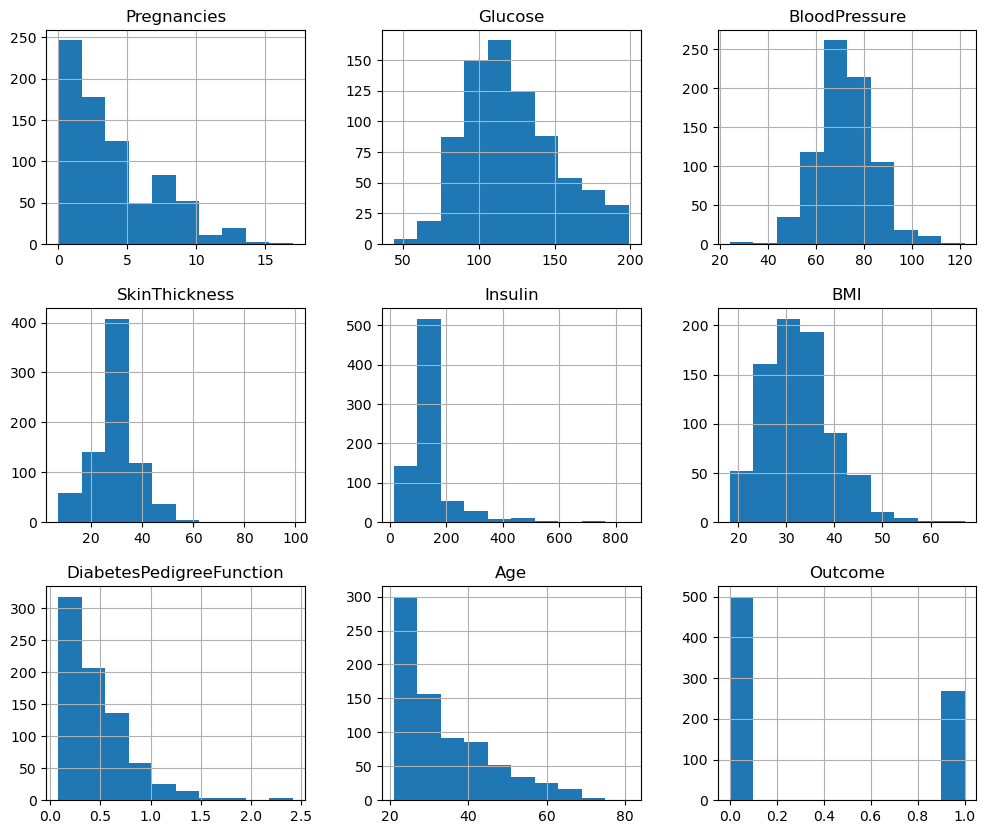

In [12]:
data.hist(figsize=(12,10))
plt.show()

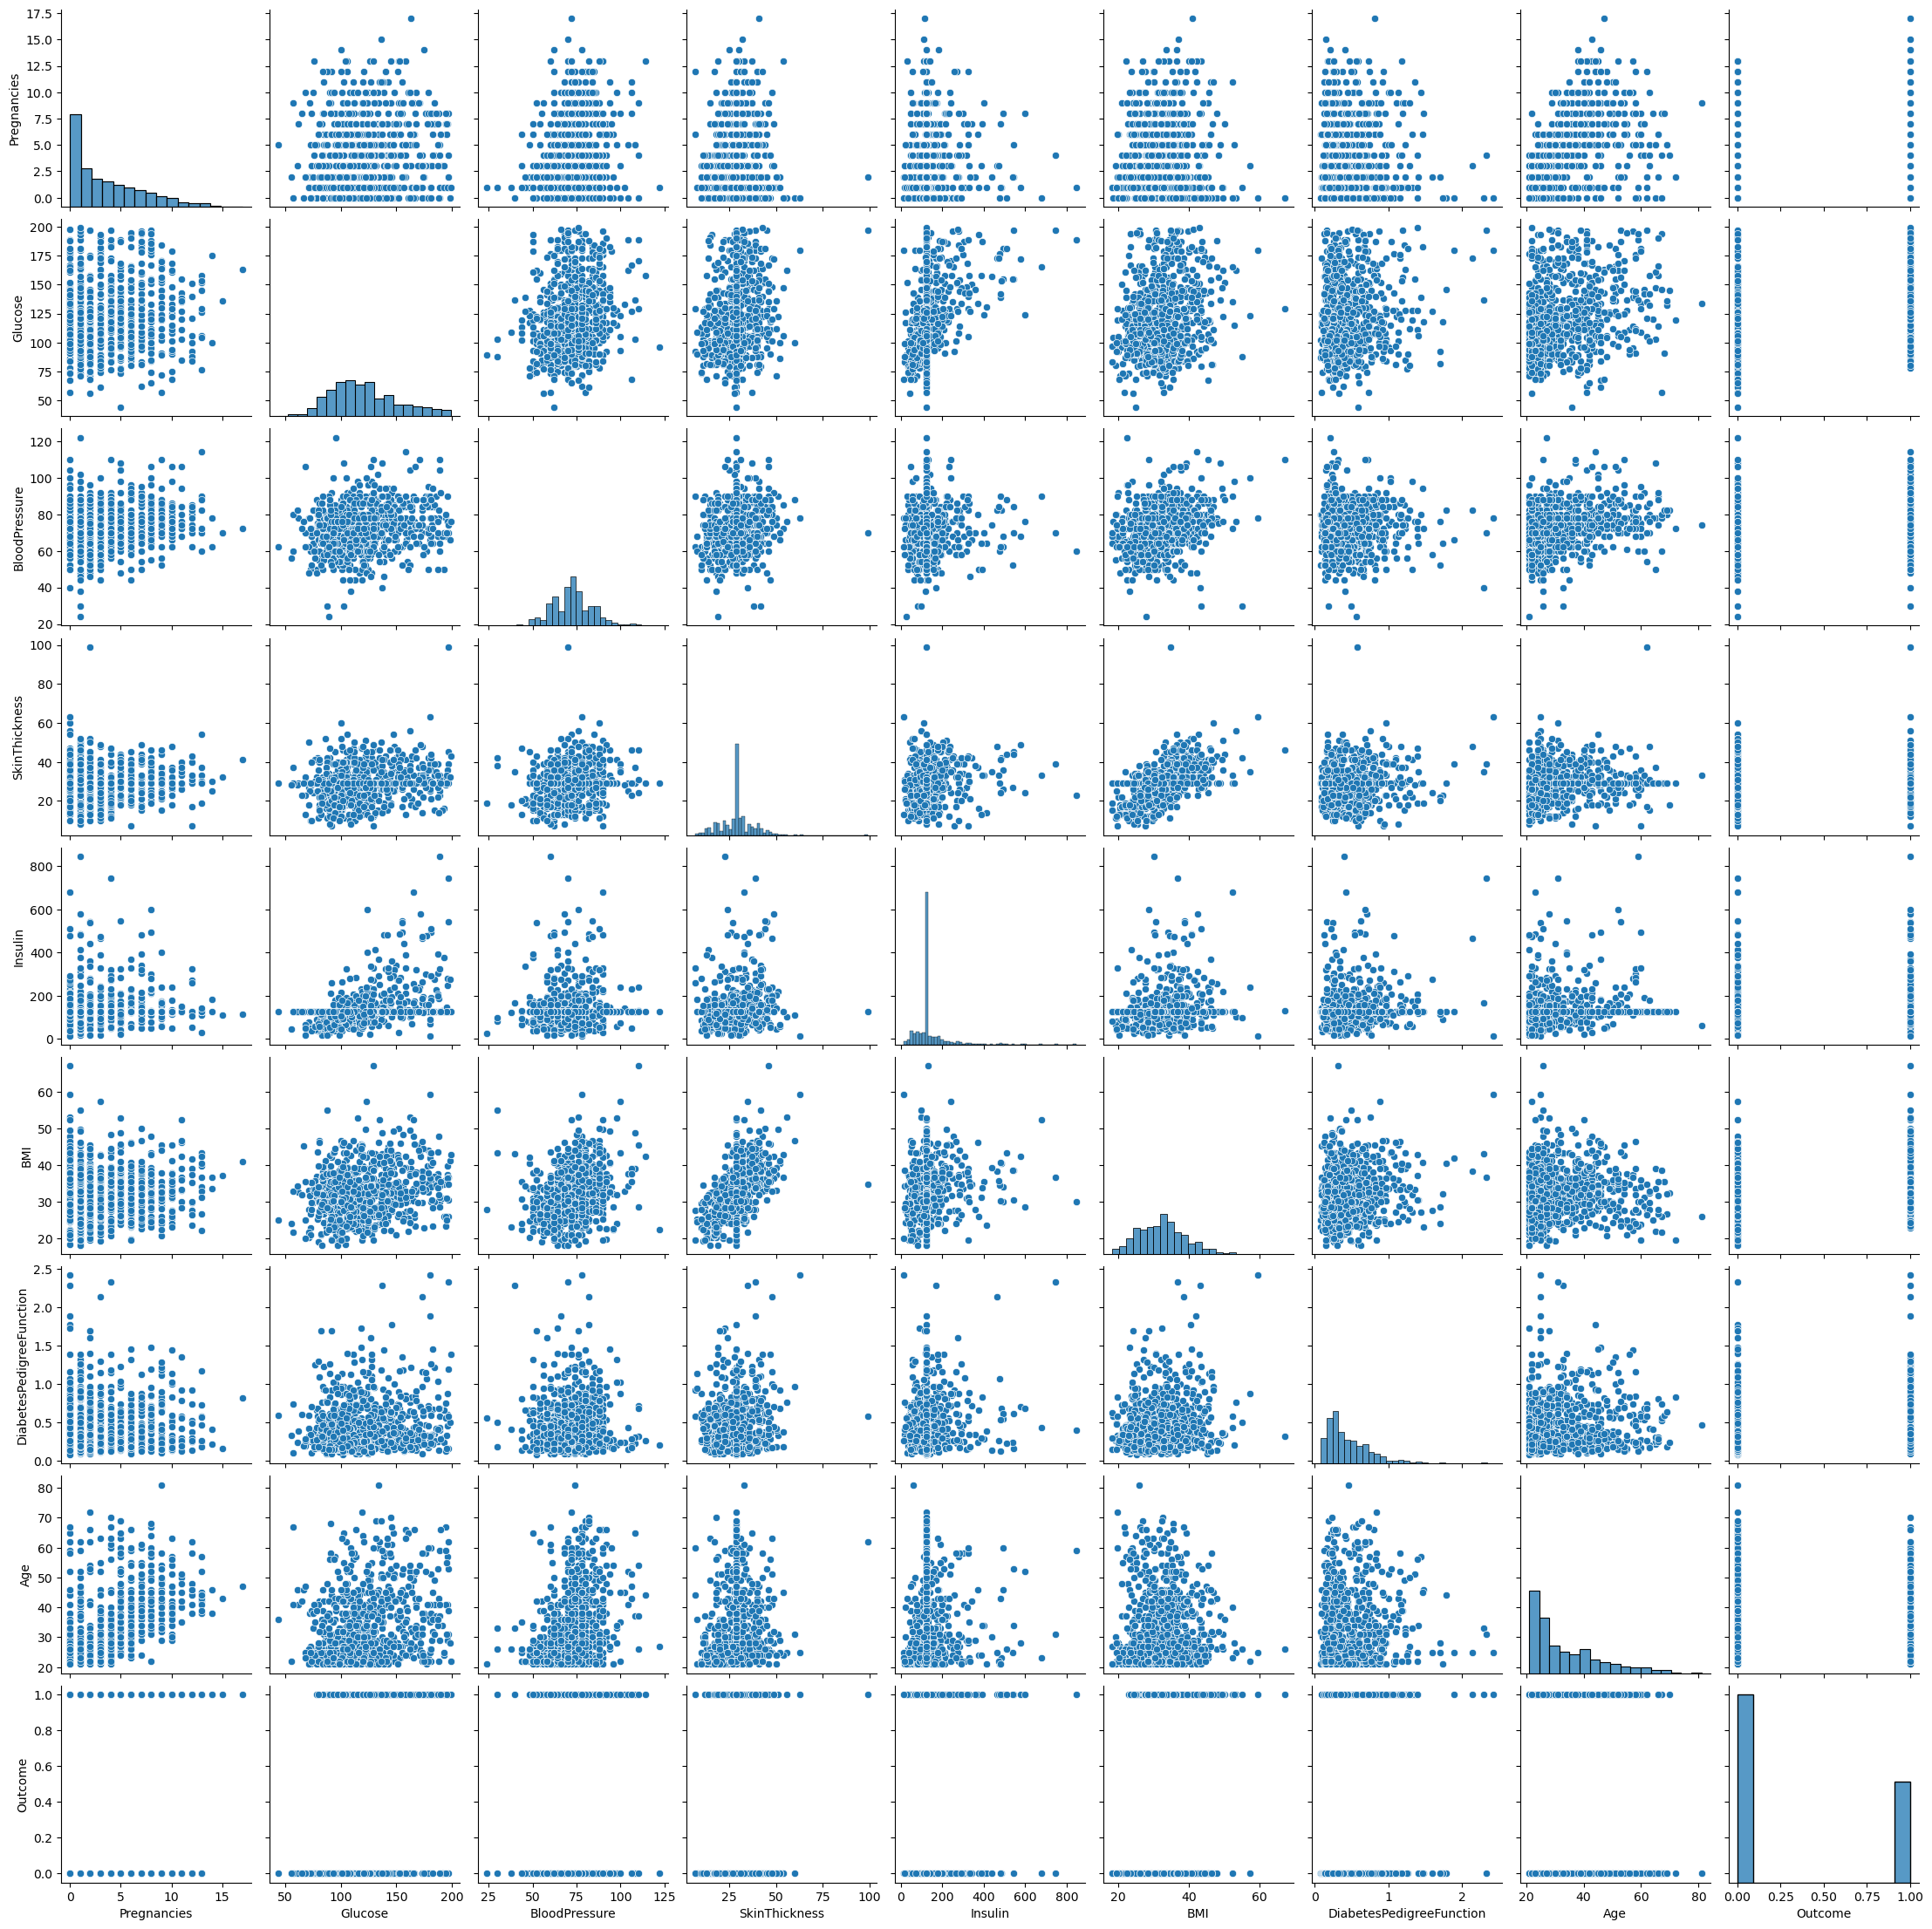

In [13]:
# pairplot
sns.pairplot(data)
plt.show()

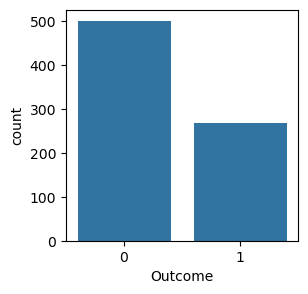

In [14]:
plt.figure(figsize=(3,3))
sns.countplot(data, x='Outcome')
plt.show()

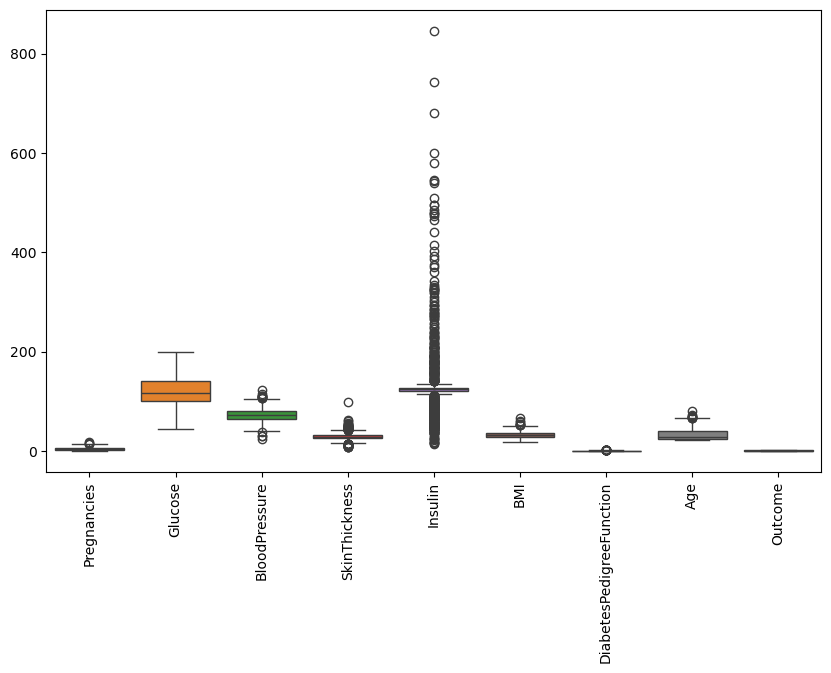

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(data)
plt.xticks(rotation=90)
plt.show()

In [16]:
# corr = data.corr()
# corr

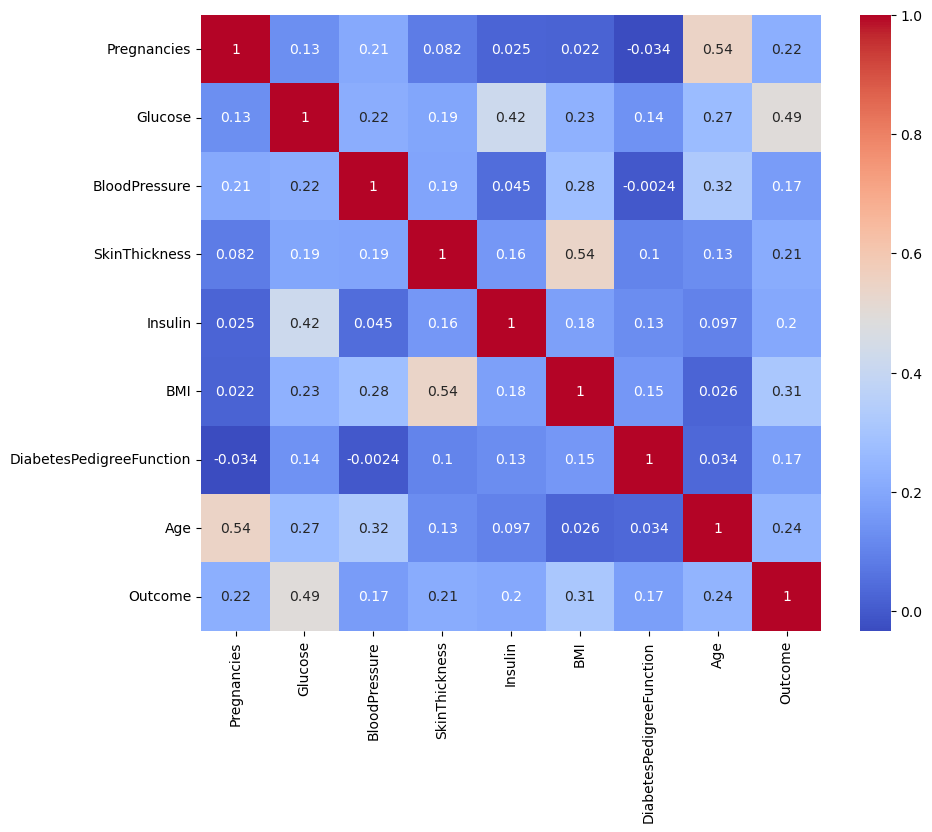

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

### Model Building

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [19]:
X = data.drop('Outcome' , axis=1)
y = data['Outcome']

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [21]:
model = LogisticRegression(max_iter=200)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [22]:
yhat_train = model.predict(X_train)
yhat_test = model.predict(X_test)

### Model Evaluation

In [23]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

#### Train the data

In [24]:
# Train
cm_train = confusion_matrix(y_train,yhat_train)
cm_train

array([[353,  48],
       [ 94, 119]])

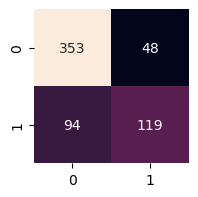

In [25]:
plt.figure(figsize=(2,2))
sns.heatmap(cm_train, annot=True,fmt='d', cbar=False)
plt.show()

In [26]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       401
           1       0.71      0.56      0.63       213

    accuracy                           0.77       614
   macro avg       0.75      0.72      0.73       614
weighted avg       0.76      0.77      0.76       614



In [27]:
auc = roc_auc_score(y_train, yhat_train)
print(f'AUC: {auc}')

AUC: 0.7194923489398569


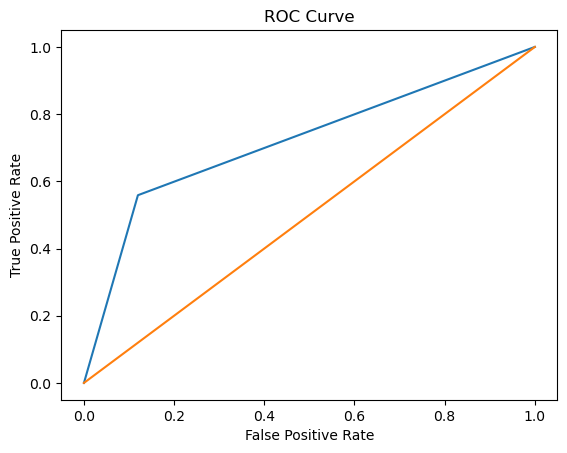

In [28]:
fpr, tpr, thresholds = roc_curve(y_train, yhat_train)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])   # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

#### Test the data

In [29]:
# test
cm_test = confusion_matrix(y_test,yhat_test)
cm_test

array([[82, 17],
       [21, 34]])

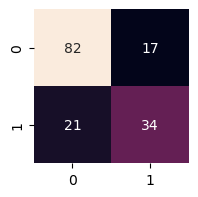

In [30]:
plt.figure(figsize=(2,2))
sns.heatmap(cm_test, annot=True,fmt='d', cbar=False)
plt.show()

In [31]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [32]:
# ROC-AUC-Score
auc = roc_auc_score(y_test, yhat_test)
print(f'AUC: {auc}')

AUC: 0.7232323232323232


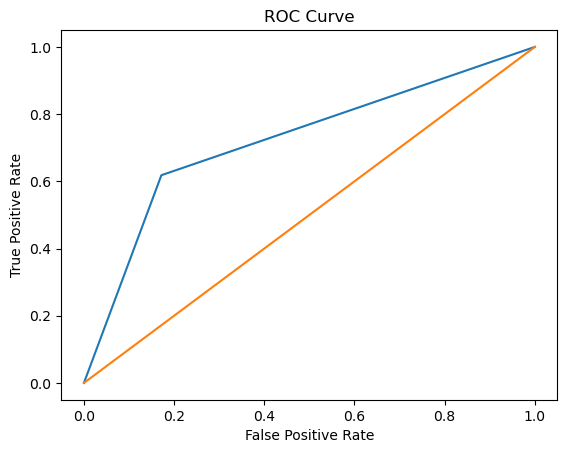

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, yhat_test)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])   # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### Interpretation

In [34]:
model.coef_

array([[ 0.0676064 ,  0.03733809, -0.01323206,  0.00771209, -0.00166859,
         0.10179545,  0.55361257,  0.03460894]])

In [35]:
X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [36]:
# coefficients
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coef)

                    Feature  Coefficient
0               Pregnancies     0.067606
1                   Glucose     0.037338
2             BloodPressure    -0.013232
3             SkinThickness     0.007712
4                   Insulin    -0.001669
5                       BMI     0.101795
6  DiabetesPedigreeFunction     0.553613
7                       Age     0.034609


In [37]:
coef['abs_coef'] = coef['Coefficient'].abs()
coef.sort_values(by='abs_coef', ascending=False)

,Feature,Coefficient,abs_coef
6,DiabetesPedigreeFunction,0.553613,0.553613
5,BMI,0.101795,0.101795
0,Pregnancies,0.067606,0.067606
1,Glucose,0.037338,0.037338
7,Age,0.034609,0.034609
2,BloodPressure,-0.013232,0.013232
3,SkinThickness,0.007712,0.007712
4,Insulin,-0.001669,0.001669


In [38]:
from pickle import dump

In [39]:
dump(model, open(r"diabetes_model.pkl", 'wb'))

### Interview Questions:

##### 1. What is the difference between precision and recall?

##### 2. What is cross-validation, and why is it important in binary classification?